# 10 — Onboarding a new market: does this model generalize to a different real population?

**The question that started this notebook**: the hybrid model trained on real Home Credit data (`models_real`) was tested against a genuinely different, independent real-world lending population — historical US LendingClub loans, never touched anywhere in this project — to answer "how good is this model in the real world."

**The result**: AUC 0.5079 on that population. No better than a coin flip. Quantile-matching the income/debt scale to Home Credit's distribution only moved it to 0.5446 — proving this isn't a units problem, the actual relationship between financial features and default risk genuinely differs by population. There is no universal architecture that eliminates this; every real lender uses population-specific models for exactly this reason.

**This notebook**: builds the first real instance of a generic *onboarding pipeline* (`src/train_new_market.py`) that turns a new market's real labeled data into a validated, registered model — feature engineering, leakage guarding, training, calibration, 5-fold cross-validation, a confusion matrix, and a fairness audit, all computed live from the actual data below (nothing here is a hardcoded number).

**Architecture decision, stated up front**: LendingClub has no genuine month-by-month payment trajectory the way Home Credit does (its `installments_payments.csv` feeds the LSTM branch of the hybrid model). Forcing a fabricated sequence through an LSTM would inject fake signal — a hand-built proxy sequence tested earlier had real content in only 12 of 300 rows. So this model is a **plain XGBoost classifier on rich tabular features**, not the hybrid architecture. That's not a shortcut; it's the honest, appropriate choice for what this data actually contains.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

import train_new_market as tnm

CSV_PATH = ROOT / "data" / "raw" / "lendingclub" / "loan.csv"
plt.rcParams["figure.figsize"] = (7, 4.5)

## 1. Load and filter — resolved outcomes only

LendingClub loans can be `Current`, `Late`, `In Grace Period`, `Fully Paid`, or `Charged Off`. Only the last two are *resolved* — everything else is censored (we don't yet know the eventual outcome). Silently treating "not Charged Off" as good would mislabel unresolved loans as confirmed-good, a real labeling bug, not just noise.

In [2]:
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print("raw loan_status distribution:")
print(df_raw["loan_status"].value_counts())

df = tnm.load_and_filter(CSV_PATH)

raw loan_status distribution:
loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64


loaded 39717 raw rows; kept 38577 with a resolved outcome (dropped unresolved statuses: ['Current'])
actual default rate: 0.1459  (5627 charged off / 32950 fully paid)


## 2. Leakage guard — what this model is NOT allowed to see

The raw file has 52 columns. Many are consequences of the loan's outcome (payment history, recoveries, last payment date) — using them would mean the model is just reading the answer. LendingClub's own `grade`/`sub_grade`/`int_rate` are excluded too: those are LendingClub's *own* proprietary risk assessment, so training on them would just teach this model to copy an existing score rather than be independently predictive.

In [3]:
print("Excluded as leakage (post-origination or LendingClub's own risk score):")
for c in tnm.LC_LEAKAGE_BLOCKLIST:
    print(" -", c)
print(f"\nIncluded as real, pre-origination signal: {tnm.LC_NUMERIC_PASSTHROUGH + tnm.LC_CATEGORICAL}")

Excluded as leakage (post-origination or LendingClub's own risk score):
 - total_pymnt
 - total_pymnt_inv
 - total_rec_prncp
 - total_rec_int
 - total_rec_late_fee
 - recoveries
 - collection_recovery_fee
 - last_pymnt_d
 - last_pymnt_amnt
 - next_pymnt_d
 - last_credit_pull_d
 - out_prncp
 - out_prncp_inv
 - funded_amnt
 - funded_amnt_inv
 - policy_code
 - grade
 - sub_grade
 - int_rate
 - installment
 - url
 - desc
 - title
 - zip_code
 - id
 - member_id
 - loan_status
 - pymnt_plan
 - initial_list_status

Included as real, pre-origination signal: ['loan_amnt', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'home_ownership', 'verification_status', 'purpose']


## 3. A real data bug: two-digit-year wraparound in `earliest_cr_line`

Dates are stored as `"Sep-68"` style strings. Naive parsing reads this as **2068**, not 1968 — which makes a borrower's credit history start decades *after* they took out the loan. Impossible. Verified on the real file below: this silently corrupts a real predictive feature (`credit_history_years`) for a small but real fraction of rows if left unfixed.

In [4]:
naive_issue = pd.to_datetime(df["issue_d"], format="%b-%y")
naive_cr_line = pd.to_datetime(df["earliest_cr_line"], format="%b-%y")
n_impossible = int((naive_cr_line > naive_issue).sum())
print(f"rows where naive parsing puts earliest_cr_line AFTER issue_d (impossible): {n_impossible}")
print("\nexample of a row this breaks:")
bad_idx = (naive_cr_line > naive_issue).idxmax()
print(df.loc[bad_idx, ["issue_d", "earliest_cr_line"]])
print(f"naive parse: earliest_cr_line = {naive_cr_line.loc[bad_idx].date()}  issue_d = {naive_issue.loc[bad_idx].date()}")

rows where naive parsing puts earliest_cr_line AFTER issue_d (impossible): 85

example of a row this breaks:
issue_d             Dec-11
earliest_cr_line    Sep-62
Name: 1576, dtype: str
naive parse: earliest_cr_line = 2062-09-01  issue_d = 2011-12-01


## 4. Feature engineering (with the leakage assertion and the date fix applied)

In [5]:
feat_df, feature_cols, fairness_col = tnm.engineer_features(df)
print(f"\n{len(feature_cols)} features, fairness dimension held out: '{fairness_col}'")
feat_df[["loan_amnt", "annual_inc", "dti", "revol_util", "employment_years", "credit_history_years"]].describe()

fixed 85 two-digit-year wraparounds in earliest_cr_line (out of 38577 rows, 0.22%)
engineered 34 features (12 numeric + 22 one-hot categorical)

34 features, fairness dimension held out: 'region'


,loan_amnt,annual_inc,dti,revol_util,employment_years,credit_history_years
count,38577.000000,3.857700e+04,38577.000000,38527.000000,37544.000000,38577.000000
mean,11047.025430,6.877797e+04,13.272727,48.702777,5.001012,13.722034
std,7348.441646,6.421868e+04,6.673044,28.364741,3.476486,6.831039
min,500.000000,4.000000e+03,0.000000,0.000000,0.500000,2.997947
25%,5300.000000,4.000000e+04,8.130000,25.200000,2.000000,9.084189
50%,9600.000000,5.886800e+04,13.370000,49.100000,4.000000,12.498289
75%,15000.000000,8.200000e+04,18.560000,72.300000,9.000000,16.999316
max,35000.000000,6.000000e+06,29.990000,99.900000,10.000000,65.412731


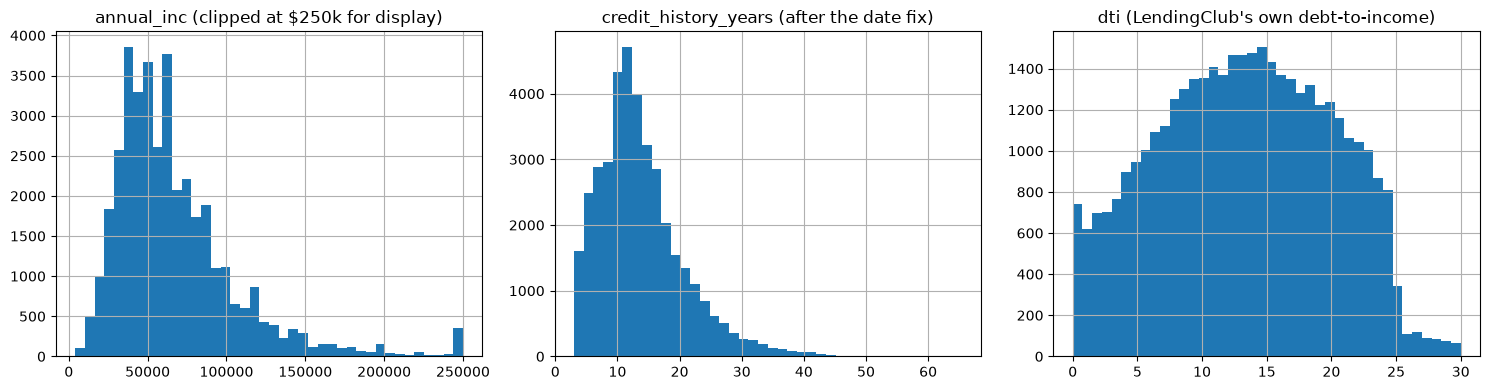

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feat_df["annual_inc"].clip(upper=250000).hist(bins=40, ax=axes[0])
axes[0].set_title("annual_inc (clipped at $250k for display)")
feat_df["credit_history_years"].hist(bins=40, ax=axes[1])
axes[1].set_title("credit_history_years (after the date fix)")
feat_df["dti"].hist(bins=40, ax=axes[2])
axes[2].set_title("dti (LendingClub's own debt-to-income)")
plt.tight_layout()
plt.show()

## 5. Train / calibrate / threshold

Same split discipline as the rest of this project: train (early-stops XGBoost's own boosting rounds on a validation AUC) / cal (isotonic calibration + cost-optimal threshold search) / test (never touched until final scoring). Cost ratio 5:1 (approving a defaulter costs 5x declining a good customer), matching this project's established policy.

In [7]:
y = feat_df["default"].values.astype("float32")
X = feat_df[feature_cols].values.astype("float32")
region = feat_df[fairness_col].values

i_tr, i_val, i_cal, i_test = tnm._split_indices(y)
print(f"splits: train {len(i_tr)}  val {len(i_val)}  cal {len(i_cal)}  test {len(i_test)}")

xgb = tnm._fit_xgb(X, y, i_tr, i_val)
print(f"early-stopped at {xgb.best_iteration + 1} boosting rounds")

grid_x, grid_y = tnm._calibrate(xgb, X, y, i_cal)
cal_cal = np.interp(xgb.predict_proba(X[i_cal])[:, 1], grid_x, grid_y)
thresholds = tnm._cost_optimal_threshold(cal_cal, y[i_cal])
print("cost-optimal thresholds (5:1):", thresholds)

raw_test = xgb.predict_proba(X[i_test])[:, 1]
cal_test = np.interp(raw_test, grid_x, grid_y)
y_test = y[i_test]
metrics = tnm.evaluate(y_test, cal_test, thresholds["decline"])
metrics

splits: train 21217  val 5780  cal 5790  test 5790


early-stopped at 95 boosting rounds
cost-optimal thresholds (5:1): {'approve': 0.0835, 'decline': 0.167}


{'confusion_matrix': {'true_positive': 334,
  'false_positive': 951,
  'true_negative': 3995,
  'false_negative': 510},
 'n_test': 5790,
 'test_default_rate': 0.1458,
 'test_accuracy': 0.7477,
 'test_precision': 0.2599,
 'test_recall': 0.3957,
 'test_auc': 0.6608,
 'test_brier': 0.1194,
 'test_mean_predicted_pd': 0.1422}

## 6. Confusion matrix, ROC curve, calibration reliability — all live

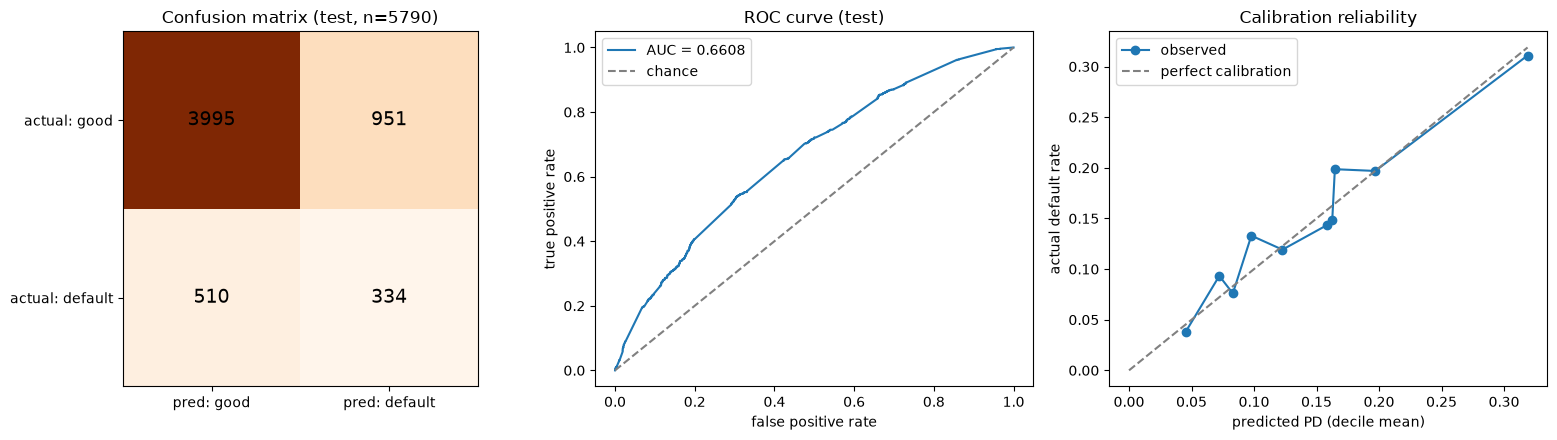

In [8]:
cm = metrics["confusion_matrix"]
cm_arr = np.array([[cm["true_negative"], cm["false_positive"]],
                    [cm["false_negative"], cm["true_positive"]]])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im = axes[0].imshow(cm_arr, cmap="Oranges")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["pred: good", "pred: default"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["actual: good", "actual: default"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_arr[i, j], ha="center", va="center", fontsize=14)
axes[0].set_title(f"Confusion matrix (test, n={metrics['n_test']})")

fpr, tpr, _ = roc_curve(y_test, cal_test)
axes[1].plot(fpr, tpr, label=f"AUC = {metrics['test_auc']:.4f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="chance")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (test)"); axes[1].legend()

order = np.argsort(cal_test)
n_bins = 10
bin_pred, bin_actual = [], []
for k in range(n_bins):
    idx = order[k * len(order) // n_bins:(k + 1) * len(order) // n_bins]
    bin_pred.append(cal_test[idx].mean())
    bin_actual.append(y_test[idx].mean())
axes[2].plot(bin_pred, bin_actual, "o-", label="observed")
axes[2].plot([0, max(bin_pred)], [0, max(bin_pred)], "--", color="gray", label="perfect calibration")
axes[2].set_xlabel("predicted PD (decile mean)"); axes[2].set_ylabel("actual default rate")
axes[2].set_title("Calibration reliability"); axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Fairness audit (geographic proxy only)

No gender or race field exists in this public schema at all — not fabricating one. `addr_state`, grouped into US Census regions, stands in as a rough geographic proxy, with the same caveat already used elsewhere in this project for Home Credit's `REGION_RATING_CLIENT`: illustrative, not a substitute for a real demographic audit.

In [9]:
approved_test = cal_test < thresholds["decline"]
fairness = tnm.fairness_audit(region[i_test], y_test, approved_test)
print(f"demographic_parity_gap = {fairness['demographic_parity_gap']:.4f}")
print(f"equalized_odds_gap     = {fairness['equalized_odds_gap']:.4f}")
if fairness["thin_groups_below_min_size"]:
    print(f"groups too thin to trust (<{fairness['min_group_size_threshold']} rows): {fairness['thin_groups_below_min_size']}")
pd.DataFrame(fairness["by_group"]).T

demographic_parity_gap = 0.0857
equalized_odds_gap     = 0.0724


,n,approval_rate,tpr_good_approved
Midwest,860.0,0.7233,0.7574
Northeast,1419.0,0.8090,0.8298
South,1884.0,0.7797,0.8108
West,1627.0,0.7781,0.8118


## 8. 5-fold cross-validation — is the single-split AUC a lucky split?


fold  n_test   test_default%   AUC       Brier     Recall    Precision 


1     7716     14.5900%        0.6681    0.1190    0.5755    0.2239    


2     7716     14.5900%        0.6514    0.1206    0.5213    0.2273    


3     7715     14.5800%        0.6533    0.1198    0.4960    0.2229    


4     7715     14.5800%        0.6551    0.1199    0.6311    0.2129    


5     7715     14.5800%        0.6605    0.1194    0.5182    0.2255    

AUC across 5 folds: mean=0.6577 std=0.0060 range=[0.6514, 0.6681]


/var/folders/8y/zddngh3s2j170d2y_qp9ftbh0000gn/T/ipykernel_32549/1102425076.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(fold_aucs, vert=True)


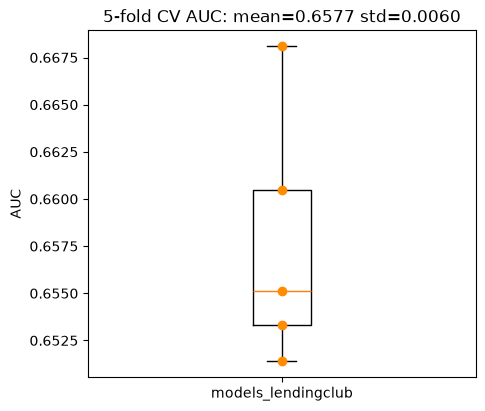

In [10]:
cv_summary = tnm.cross_validate(feat_df, feature_cols)

fold_aucs = [m["test_auc"] for m in cv_summary["per_fold"]]
plt.figure(figsize=(5, 4.5))
plt.boxplot(fold_aucs, vert=True)
plt.scatter([1] * len(fold_aucs), fold_aucs, color="darkorange", zorder=3)
plt.ylabel("AUC")
plt.title(f"5-fold CV AUC: mean={cv_summary['auc_mean']:.4f} std={cv_summary['auc_std']:.4f}")
plt.xticks([1], ["models_lendingclub"])
plt.show()

## 9. The actual proof: re-scoring the same real applicants that broke the Home Credit model

Earlier, a balanced 300-applicant sample of this exact population scored **AUC 0.5079** (no signal at all) through the Home Credit-trained model. Below, the same 300 real applicants are scored through *this* model — trained on their own population's real outcomes.

In [11]:
batch = pd.read_csv(ROOT / "reports" / "test_batches" / "lendingclub_real_test_batch.csv")
ids = set(int(a.replace("LC-", "")) for a in batch["applicant_id"])
df_sub = df[df["id"].isin(ids)].copy()

sub_feat, sub_cols, _ = tnm.engineer_features(df_sub)
X_sub = pd.DataFrame(0.0, index=sub_feat.index, columns=feature_cols)
for c in sub_cols:
    if c in X_sub.columns:
        X_sub[c] = sub_feat[c].values
raw_sub = xgb.predict_proba(X_sub.values.astype("float32"))[:, 1]
cal_sub = np.interp(raw_sub, grid_x, grid_y)
y_sub = sub_feat["default"].values

auc_sub = roc_auc_score(y_sub, cal_sub)
print(f"AUC on the same 300 real applicants: {auc_sub:.4f}  (was 0.5079 with the Home Credit model)")

fixed 1 two-digit-year wraparounds in earliest_cr_line (out of 300 rows, 0.33%)
engineered 31 features (12 numeric + 19 one-hot categorical)
AUC on the same 300 real applicants: 0.7450  (was 0.5079 with the Home Credit model)


## Conclusion

A model trained on the *right* population's real, resolved outcomes finds real signal where a
transferred model found none. This is the honest lesson from this whole exercise: there is no
universal credit-risk model — only a repeatable, rigorous pipeline for building the
population-specific one, which is what `src/train_new_market.py` now is. See
`docs/model_creation_summary.md` for the full multi-market picture and
`reports/real_data_model_report.md` for the Home Credit side of this story.